# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [53]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime
import geopandas as gpd

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [54]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [55]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/birds/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


In [56]:
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_group']
))

# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)


In [57]:
combined_df = combined_df[combined_df['migration_group']=='nocturnal']

In [58]:
combined_df

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
11157,Curlew Sandpiper,Calidris ferruginea,2.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,"Unnamed Road, AL (40.981, 19.467)",L6241216,P,40.981300,19.466977,2017-09-03,obsr843351,S38990238,Traveling,nocturnal
11158,Curlew Sandpiper,Calidris ferruginea,3.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,Divjaka Resort,L6845193,H,40.978473,19.477816,2022-05-21,obsr1419603,S110856389,Traveling,nocturnal
11159,Curlew Sandpiper,Calidris ferruginea,1.0,NaN,Albania,AL,LezhÃ«,AL-08,NaN,NaN,NaN,Marsh Near Shengjin,L49427675,P,41.800037,19.614249,2017-04-07,obsr1235266,S258330513,Historical,nocturnal
11160,Curlew Sandpiper,Calidris ferruginea,5.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Butrint National Park,L7565192,H,39.743824,20.019064,2017-09-08,obsr2750692,S119100961,Historical,nocturnal
11161,Curlew Sandpiper,Calidris ferruginea,4.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Narta Lagoon,L3811665,H,40.526327,19.427261,2017-09-14,obsr2750692,S119109499,Historical,nocturnal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830736,Garganey,Spatula querquedula,1.0,NaN,Ukraine,UA,Chernihivs'ka Oblast',UA-74,NaN,NaN,NaN,ÐÐµÑÐµÐ¼Ð¸ÑÑÐºÐµ Ð§ÐµÑÐ½ÑÐ³ÑÐ²ÑÑÐºÐ° ...,L9637648,P,50.883452,30.832099,2019-07-14,obsr804075,S58161951,Traveling,nocturnal
830737,Garganey,Spatula querquedula,1.0,NaN,Ukraine,UA,Chernihivs'ka Oblast',UA-74,NaN,NaN,NaN,"Avtoshlyakh T 1008, Chernihivs'ka oblast, UA (...",L9648970,P,50.884108,30.869386,2019-07-14,obsr1129593,S58219196,Traveling,nocturnal
830738,Garganey,Spatula querquedula,15.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, Ð Ð¾ÐºÐ¸ÑÐ½Ðµ, Ð§ÐµÑÐ½ÑÐ²ÐµÑ...",L14171926,P,48.335489,26.174703,2021-03-27,obsr1524677,S84171334,Traveling,nocturnal
830739,Garganey,Spatula querquedula,7.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Ð§ÐµÑÐ½ÑÐ²ÑÑ OÐ±'ÑÐ·Ð½Ð°, Ð§ÐµÑÐ½ÑÐ²ÑÑ...",L11373073,P,48.278235,26.011840,2021-04-03,obsr1524677,S84655829,Traveling,nocturnal


In [59]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
11157,Curlew Sandpiper,Calidris ferruginea,2.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,"Unnamed Road, AL (40.981, 19.467)",L6241216,P,40.981300,19.466977,2017-09-03,obsr843351,S38990238,Traveling,nocturnal
11158,Curlew Sandpiper,Calidris ferruginea,3.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,Divjaka Resort,L6845193,H,40.978473,19.477816,2022-05-21,obsr1419603,S110856389,Traveling,nocturnal
11159,Curlew Sandpiper,Calidris ferruginea,1.0,NaN,Albania,AL,LezhÃ«,AL-08,NaN,NaN,NaN,Marsh Near Shengjin,L49427675,P,41.800037,19.614249,2017-04-07,obsr1235266,S258330513,Historical,nocturnal
11160,Curlew Sandpiper,Calidris ferruginea,5.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Butrint National Park,L7565192,H,39.743824,20.019064,2017-09-08,obsr2750692,S119100961,Historical,nocturnal
11161,Curlew Sandpiper,Calidris ferruginea,4.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Narta Lagoon,L3811665,H,40.526327,19.427261,2017-09-14,obsr2750692,S119109499,Historical,nocturnal


In [60]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] != 2026]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2025-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [61]:
combined_df = combined_df[combined_df['year'] < 2023]

## 3. Basic Statistics

In [62]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 633,427
Number of countries: 46
Number of states/regions: 617
Number of counties: 934
Number of unique species: 8
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 18330

Observations with count data: 633,427 (100.0%)
Total birds counted: 14,521,636
Average count per observation: 22.93
Median count: 2
Maximum count in single observation: 140,000
Minimum count: 1


### outlier removal for col 'howMany'

In [63]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 5.0
IQR: 4.0
Lower bound: -5.0
Upper bound: 11.0

Total outliers: 85,048 (13.43% of data)

Outlier summary:
count     85048.000000
mean        153.927947
std        2103.632504
min          12.000000
25%          16.000000
50%          25.000000
75%          50.000000
max      140000.000000
Name: howMany, dtype: float64


In [64]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
20.0     8203
15.0     6890
12.0     6805
30.0     5343
50.0     3671
25.0     3479
14.0     3173
40.0     3060
13.0     2624
16.0     2404
18.0     2142
100.0    2014
17.0     1739
60.0     1636
35.0     1471
22.0     1264
19.0     1206
80.0     1110
200.0    1105
23.0     1044
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-5-50        65129
51-100       10555
101-500       7673
501-1000       751
1001-5000      686
5000+          254
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    12
  Max outlier value:    140,000
  Mean outlier value:   153.93
  Median outlier value: 25


In [65]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 9,364

Locality Type Distribution:
LOCALITY TYPE
H    7614
P    1750
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    81.31%
P    18.69%
Name: proportion, dtype: object


#### dropping outliers

In [66]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 633,427
Rows after:  624,063
Rows dropped: 9,364 (1.48% of data)


## 4. Analysis by Country

In [67]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 194630


In [68]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain              192315               8             19               48            1028279.0
          GB         United Kingdom              113149               8              4              102             622114.0
          PT               Portugal               70672               8             20              224             453969.0
          DE                Germany               26859               8             16              289             153513.0
          FR                 France               24198               8             13               95             143836.0
          PL                 Poland               20617               8             16                0             167523.0
          SE                 Sweden               19337               8             21                

In [69]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          ES                  Spain              192315               8             19               48            1028279.0              5940
          GB         United Kingdom              113149               8              4              102             622114.0              4573
          PT               Portugal               70672               8             20              224             453969.0              2407
          FR                 France               24198               8             13               95             143836.0              1595
          DE                Germany               26859               8             16              289             153513.0              1240
          NL            Netherlands               12533               8             12                2              80

### relative to number of observers

In [70]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

# Calculate per-observer metrics
country_stats['Obs per Observer']      = (country_stats['Total Observations'] / country_stats['Unique Observers']).round(1)
# country_stats['Species per Observer']  = (country_stats['Unique Species']      / country_stats['Unique Observers']).round(1)
# country_stats['Birds per Observer']    = (country_stats['Total Birds Counted'] / country_stats['Unique Observers']).round(1)
# country_stats['Counties per Observer'] = (country_stats['Unique Counties']     / country_stats['Unique Observers']).round(2)

country_stats = country_stats.sort_values('Obs per Observer', ascending=False)

print("\nSTATISTICS BY COUNTRY (relative to unique observers)")
print("="*150)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY (relative to unique observers)
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers  Obs per Observer
          MD                Moldova                1541               7             30                0              17783.0                28              55.0
          CZ         Czech Republic               16387               8             14                0              99665.0               356              46.0
          PL                 Poland               20617               8             16                0             167523.0               587              35.1
          RS                 Serbia                4451               8             18                0              39045.0               130              34.2
          ES                  Spain              192315               8             19               48            1028279.0              594

### year and locality type

In [71]:
yearly_obs = combined_df.groupby('year').size().sort_index()

print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")
        locality_counts = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')
            .size()
            .sort_values(ascending=False)
        )
        for locality, loc_count in locality_counts.items():
            print(f"    {locality}: {loc_count:,}")

        h = locality_counts.get('H', 0)
        p = locality_counts.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{diff:,}")


Observations by Year:
  2017: 55,212
    H: 44,232
    P: 10,980
    H - P = +33,252
  2018: 64,290
    H: 52,126
    P: 12,164
    H - P = +39,962
  2019: 84,721
    H: 70,100
    P: 14,621
    H - P = +55,479
  2020: 96,349
    H: 80,554
    P: 15,795
    H - P = +64,759
  2021: 138,340
    H: 116,127
    P: 22,213
    H - P = +93,914
  2022: 185,151
    H: 157,070
    P: 28,081
    H - P = +128,989


## 5. Species Analysis

In [72]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
     Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
 Green Sandpiper     Tringa ochropus              173660               44           557     413116.0
            Ruff     Calidris pugnax              109964               42           491     951843.0
      Sanderling       Calidris alba               85484               42           305     984336.0
  Wood Sandpiper     Tringa glareola               74871               42           523     418857.0
        Garganey Spatula querquedula               52675               43           511     233464.0
    Little Stint     Calidris minuta               51689               43           383     286413.0
        Red Knot    Calidris canutus               39126               40           273     316233.0
Curlew Sandpiper Calidris ferruginea               36594               39           345     184204.0


## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 55,212
  2018: 64,290
  2019: 84,721
  2020: 96,349
  2021: 138,340
  2022: 185,151

Observations by month of 2017
  January: 2,849
  February: 1,794
  March: 3,842
  April: 7,541
  May: 5,813
  June: 1,984
  July: 3,973
  August: 7,817
  September: 8,907
  October: 5,025
  November: 2,735
  December: 2,932
  → Peak migration month: September (8,907 observations)

Observations by month of 2018
  January: 3,535
  February: 2,784
  March: 4,353
  April: 8,011
  May: 8,187
  June: 2,708
  July: 5,603
  August: 9,404
  September: 9,121
  October: 4,511
  November: 2,839
  December: 3,234
  → Peak migration month: August (9,404 observations)

Observations by month of 2019
  January: 4,125
  February: 3,241
  March: 6,885
  April: 11,891
  May: 9,557
  June: 2,907
  July: 7,101
  August: 12,946
  September: 12,124
  October: 6,055
  November: 3,853
  December: 4,036
  → Peak migration month: August (12,946 observations)

Observations by month

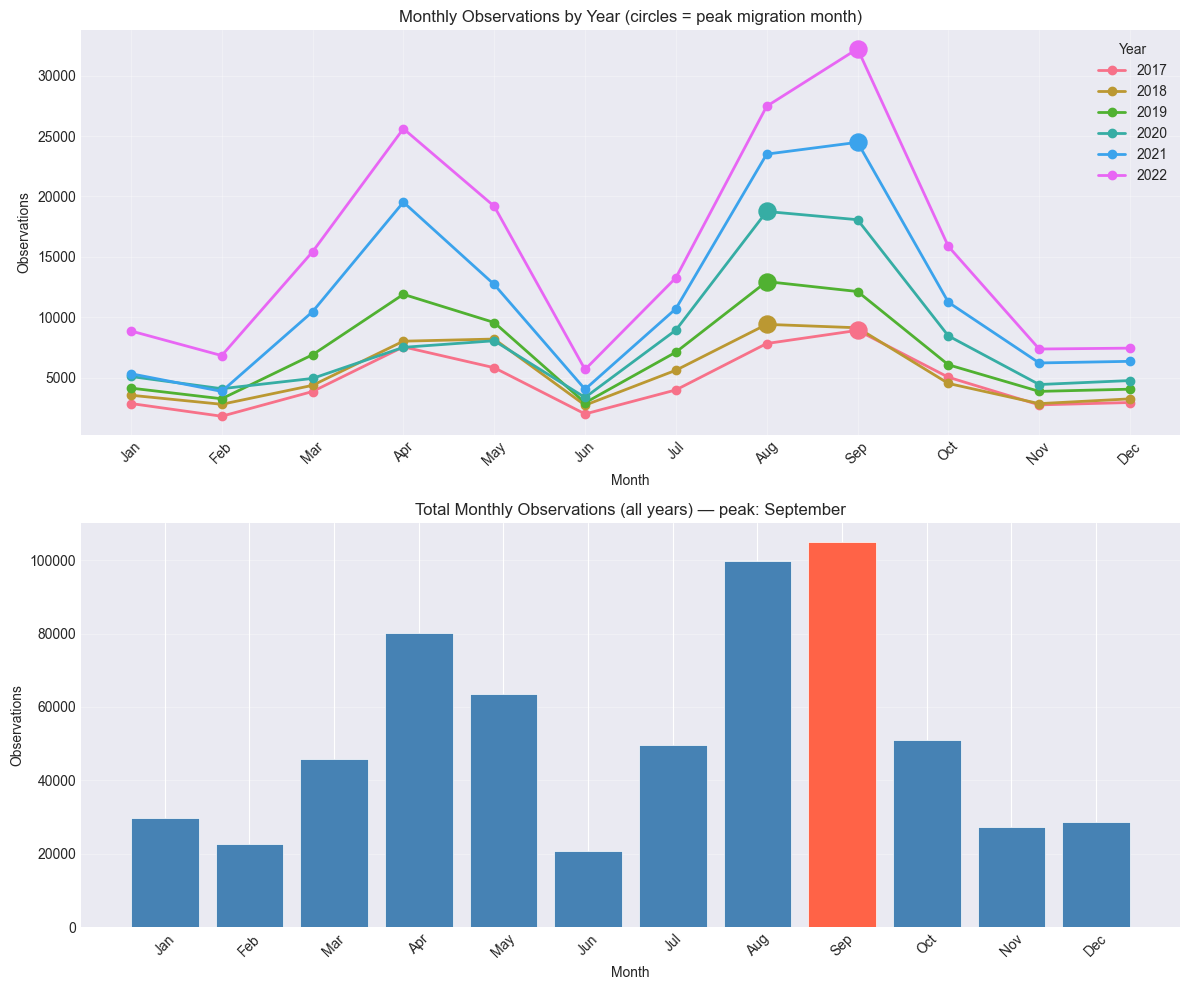

In [73]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [74]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 55,212.0 observations | 331,686.0 number of birds counted
  2018: 64,290.0 observations | 396,001.0 number of birds counted
  2019: 84,721.0 observations | 510,933.0 number of birds counted
  2020: 96,349.0 observations | 596,135.0 number of birds counted
  2021: 138,340.0 observations | 842,900.0 number of birds counted
  2022: 185,151.0 observations | 1,110,811.0 number of birds counted


In [75]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 83.28
    Avg obs per observer: 13.86
    Avg bird per observer: 80.05
    Avg obs per observer: 13.00
    Avg bird per observer: 84.84
    Avg obs per observer: 14.07
    Avg bird per observer: 100.87
    Avg obs per observer: 16.30
    Avg bird per observer: 105.20
    Avg obs per observer: 17.27
    Avg bird per observer: 102.58
    Avg obs per observer: 17.10


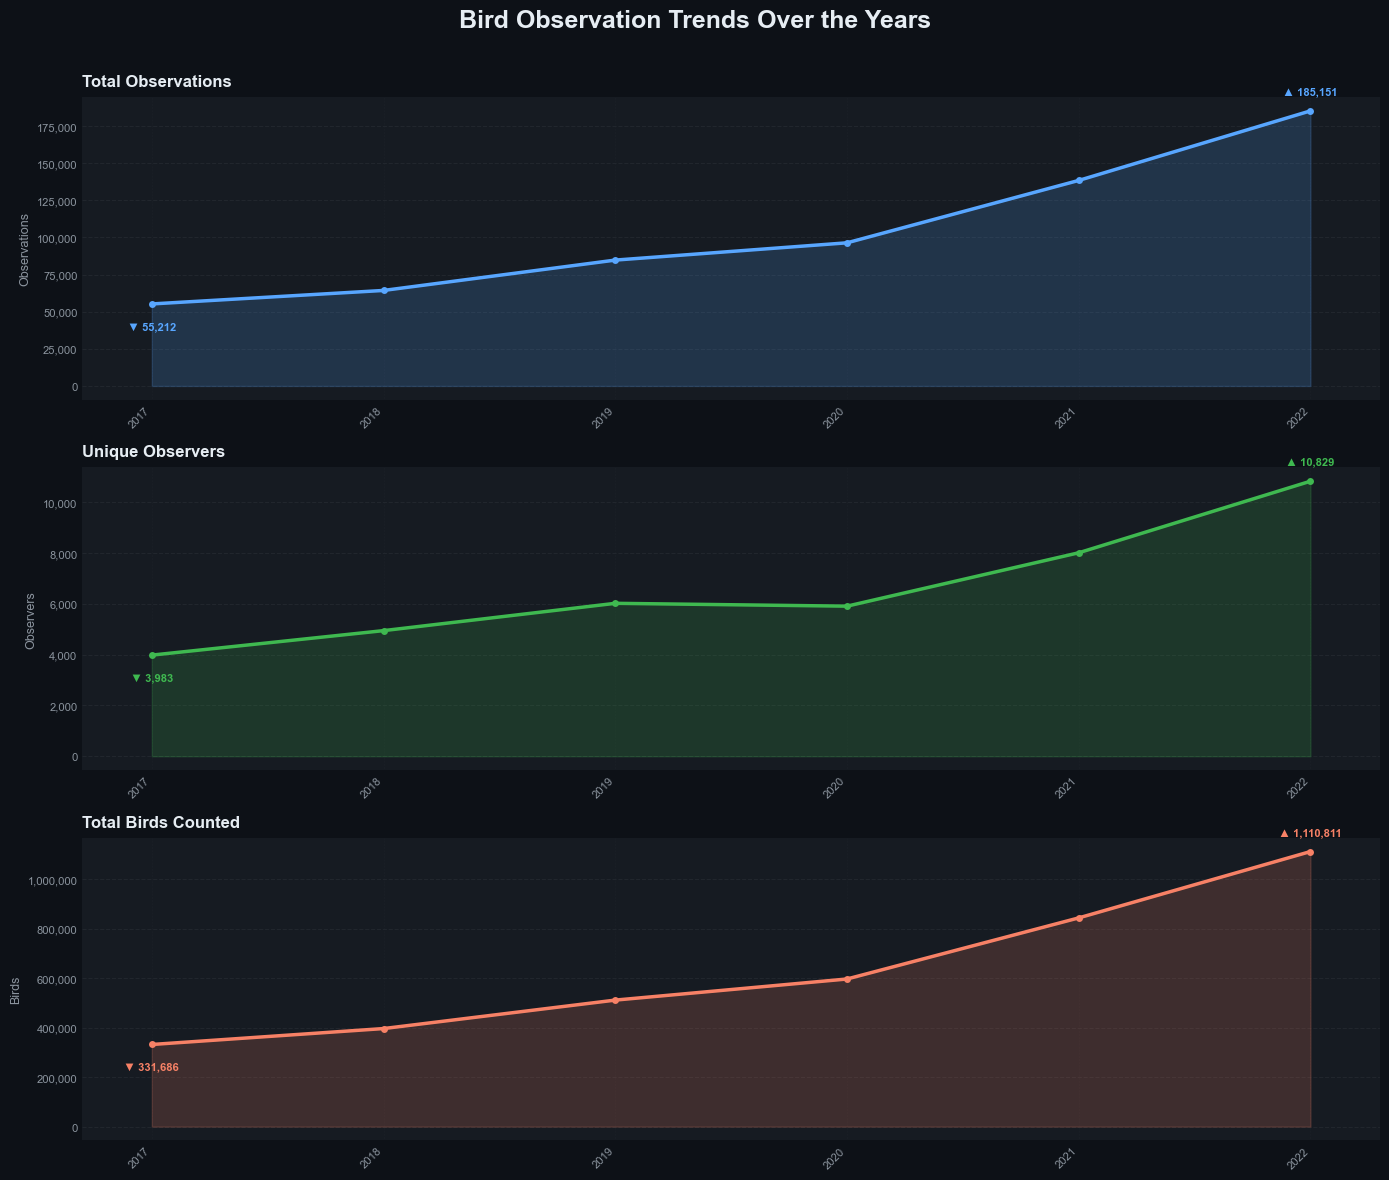

Plot saved to yearly_trends.png


In [76]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

### 8.3 Migration Pattern Analysis by Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [77]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Autumn Migration (Late Aug to Early Dec): 234,174 observations
  Spring Migration (Mid-Mar to Mid-Jun): 184,670 observations
  Summer (Jul to Early Aug): 108,548 observations
  Winter (Late Dec to Early Mar): 96,671 observations


## 7. Distance to cities

In [78]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [79]:
df_migratory = combined_df

In [80]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree on city coordinates ---
# convert lat/lon to radians for accurate distance calculation
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# find closest city for each bird observation ---
birds_rad = np.radians(df_migratory[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# convert distance from radians to kilometers (Earth radius = 6371 km)
df_migratory['closest_city'] = cities['NAME'].iloc[indices].values
df_migratory['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migratory['distance_km'] = np.round(distances * 6371, 2)

df_migratory

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group,obsDt,year,month,day_of_week,day_of_year,howMany,season,closest_city,closest_city_country,distance_km
11157,Curlew Sandpiper,Calidris ferruginea,2.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,"Unnamed Road, AL (40.981, 19.467)",L6241216,P,40.981300,19.466977,2017-09-03,obsr843351,S38990238,Traveling,nocturnal,2017-09-03,2017,9,6,246,2.0,Autumn Migration (Late Aug to Early Dec),Lushnjë,Albania,28.07
11158,Curlew Sandpiper,Calidris ferruginea,3.0,NaN,Albania,AL,Fier,AL-04,NaN,NaN,NaN,Divjaka Resort,L6845193,H,40.978473,19.477816,2022-05-21,obsr1419603,S110856389,Traveling,nocturnal,2022-05-21,2022,5,5,141,3.0,Spring Migration (Mid-Mar to Mid-Jun),Lushnjë,Albania,26.83
11159,Curlew Sandpiper,Calidris ferruginea,1.0,NaN,Albania,AL,LezhÃ«,AL-08,NaN,NaN,NaN,Marsh Near Shengjin,L49427675,P,41.800037,19.614249,2017-04-07,obsr1235266,S258330513,Historical,nocturnal,2017-04-07,2017,4,4,97,1.0,Spring Migration (Mid-Mar to Mid-Jun),Lezhë,Albania,4.62
11160,Curlew Sandpiper,Calidris ferruginea,5.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Butrint National Park,L7565192,H,39.743824,20.019064,2017-09-08,obsr2750692,S119100961,Historical,nocturnal,2017-09-08,2017,9,4,251,5.0,Autumn Migration (Late Aug to Early Dec),Sarandë,Albania,14.96
11161,Curlew Sandpiper,Calidris ferruginea,4.0,NaN,Albania,AL,VlorÃ«,AL-12,NaN,NaN,NaN,Narta Lagoon,L3811665,H,40.526327,19.427261,2017-09-14,obsr2750692,S119109499,Historical,nocturnal,2017-09-14,2017,9,3,257,4.0,Autumn Migration (Late Aug to Early Dec),Vlorë,Albania,9.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830736,Garganey,Spatula querquedula,1.0,NaN,Ukraine,UA,Chernihivs'ka Oblast',UA-74,NaN,NaN,NaN,ÐÐµÑÐµÐ¼Ð¸ÑÑÐºÐµ Ð§ÐµÑÐ½ÑÐ³ÑÐ²ÑÑÐºÐ° ...,L9637648,P,50.883452,30.832099,2019-07-14,obsr804075,S58161951,Traveling,nocturnal,2019-07-14,2019,7,6,195,1.0,Summer (Jul to Early Aug),Brovary,Ukraine,43.64
830737,Garganey,Spatula querquedula,1.0,NaN,Ukraine,UA,Chernihivs'ka Oblast',UA-74,NaN,NaN,NaN,"Avtoshlyakh T 1008, Chernihivs'ka oblast, UA (...",L9648970,P,50.884108,30.869386,2019-07-14,obsr1129593,S58219196,Traveling,nocturnal,2019-07-14,2019,7,6,195,1.0,Summer (Jul to Early Aug),Brovary,Ukraine,44.45
830738,Garganey,Spatula querquedula,15.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, Ð Ð¾ÐºÐ¸ÑÐ½Ðµ, Ð§ÐµÑÐ½ÑÐ²ÐµÑ...",L14171926,P,48.335489,26.174703,2021-03-27,obsr1524677,S84171334,Traveling,nocturnal,2021-03-27,2021,3,5,86,15.0,Spring Migration (Mid-Mar to Mid-Jun),Chernivtsi,Ukraine,28.35
830739,Garganey,Spatula querquedula,7.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Ð§ÐµÑÐ½ÑÐ²ÑÑ OÐ±'ÑÐ·Ð½Ð°, Ð§ÐµÑÐ½ÑÐ²ÑÑ...",L11373073,P,48.278235,26.011840,2021-04-03,obsr1524677,S84655829,Traveling,nocturnal,2021-04-03,2021,4,5,93,7.0,Spring Migration (Mid-Mar to Mid-Jun),Chernivtsi,Ukraine,10.48


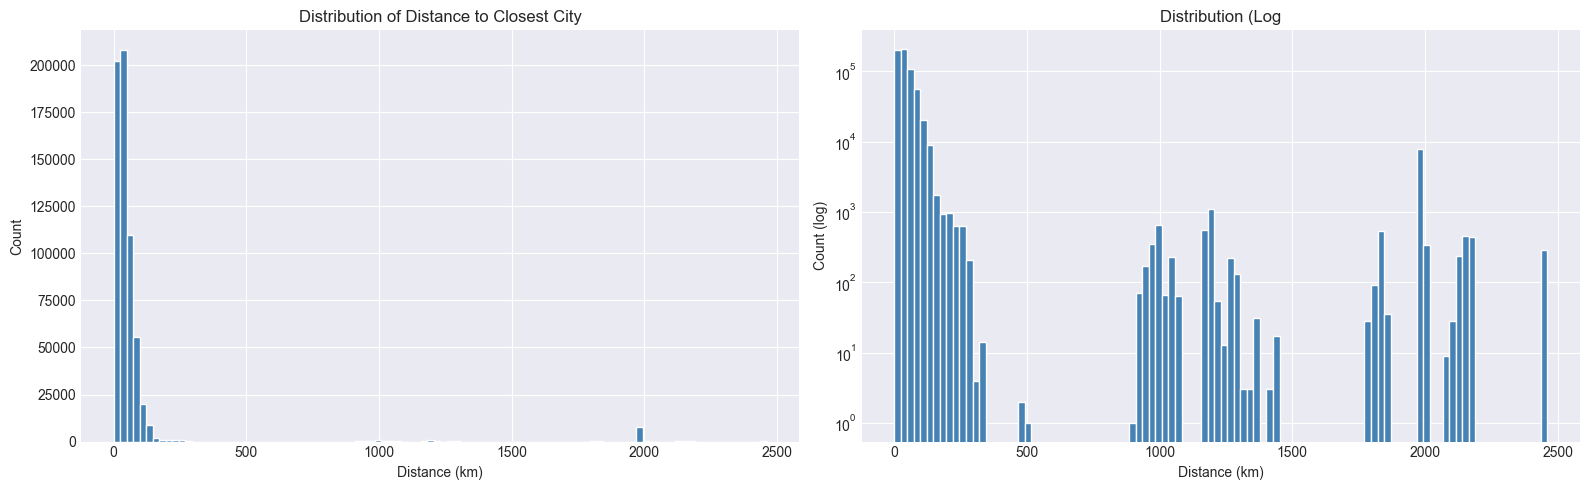

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migratory['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

### Distance Aggregations

The following cells calculate the average distance to the closest city across three groupings:
1. **Per year** — how the average distance changes over time
2. **Per species** — average across all years for each species
3. **Per species per year** — the most granular breakdown

In [82]:
# --- 1. Average distance to closest city per year ---
dist_by_year = (
    df_migratory
    .dropna(subset=['distance_km', 'year'])
    .groupby('year')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('year')
)
dist_by_year['year'] = dist_by_year['year'].astype(int)

print("Average distance to closest city per year:")
print(dist_by_year.to_string(index=False))

Average distance to closest city per year:
 year  mean_distance_km  median_distance_km  n_observations
 2017         94.602404               35.26           55212
 2018         93.723886               35.26           64290
 2019         85.283017               35.37           84721
 2020         80.070039               35.62           96349
 2021         81.916525               36.11          138340
 2022         72.521993               35.68          185151


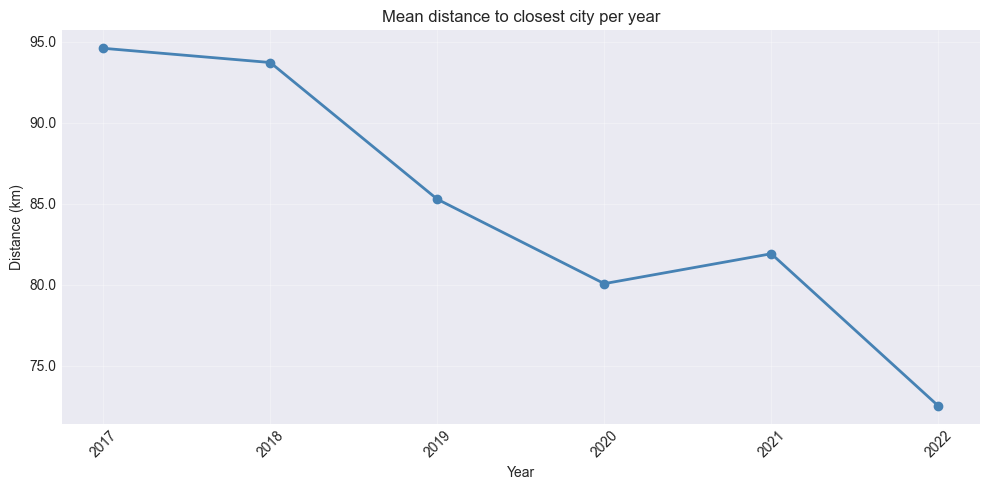

In [83]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dist_by_year['year'], dist_by_year['mean_distance_km'],
        color='steelblue', marker='o', linewidth=2, markersize=6)

ax.set_xticks(dist_by_year['year'])
ax.set_xticklabels(dist_by_year['year'], rotation=45)
ax.set_title('Mean distance to closest city per year')
ax.set_xlabel('Year')
ax.set_ylabel('Distance (km)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

plt.tight_layout()
plt.show()

In [84]:
# --- 2. Average distance to closest city per species (across all years) ---
dist_by_species = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME'])
    .groupby('COMMON NAME')['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values('mean_distance_km', ascending=False)
)

print("Average distance to closest city per species (all years combined):")
print(dist_by_species.to_string(index=False))

Average distance to closest city per species (all years combined):
     COMMON NAME  mean_distance_km  median_distance_km  n_observations
      Sanderling        158.837963               34.62           85484
        Red Knot        129.793454               38.99           39126
Curlew Sandpiper        119.619915               35.26           36594
    Little Stint         97.890082               35.65           51689
            Ruff         74.425911               37.93          109964
  Wood Sandpiper         52.292325               35.17           74871
 Green Sandpiper         48.148268               35.56          173660
        Garganey         45.450144               32.55           52675


In [85]:
# --- 3. Average distance to closest city per species per year ---
dist_by_species_year = (
    df_migratory
    .dropna(subset=['distance_km', 'COMMON NAME', 'year'])
    .groupby(['COMMON NAME', 'year'])['distance_km']
    .agg(mean_distance_km='mean', median_distance_km='median', n_observations='count')
    .reset_index()
    .sort_values(['COMMON NAME', 'year'])
)
dist_by_species_year['year'] = dist_by_species_year['year'].astype(int)

print("Average distance to closest city per species per year:")
print(dist_by_species_year.to_string(index=False))

# Optionally pivot for a cleaner species × year view
pivot_mean = dist_by_species_year.pivot(index='COMMON NAME', columns='year', values='mean_distance_km').round(2)
print("\nPivot table — mean distance (km) by species × year:")
print(pivot_mean.to_string())

Average distance to closest city per species per year:
     COMMON NAME  year  mean_distance_km  median_distance_km  n_observations
Curlew Sandpiper  2017        157.199957              35.030            3004
Curlew Sandpiper  2018        122.924719              34.620            3785
Curlew Sandpiper  2019        107.419646              34.855            4854
Curlew Sandpiper  2020        112.330849              35.260            6045
Curlew Sandpiper  2021        150.485339              37.830            6932
Curlew Sandpiper  2022         99.904219              35.260           11974
        Garganey  2017         39.458499              33.920            4389
        Garganey  2018         51.177531              34.130            6181
        Garganey  2019         51.197295              32.190            7094
        Garganey  2020         45.505455              30.820            6346
        Garganey  2021         42.729571              32.000           12157
        Garganey  202

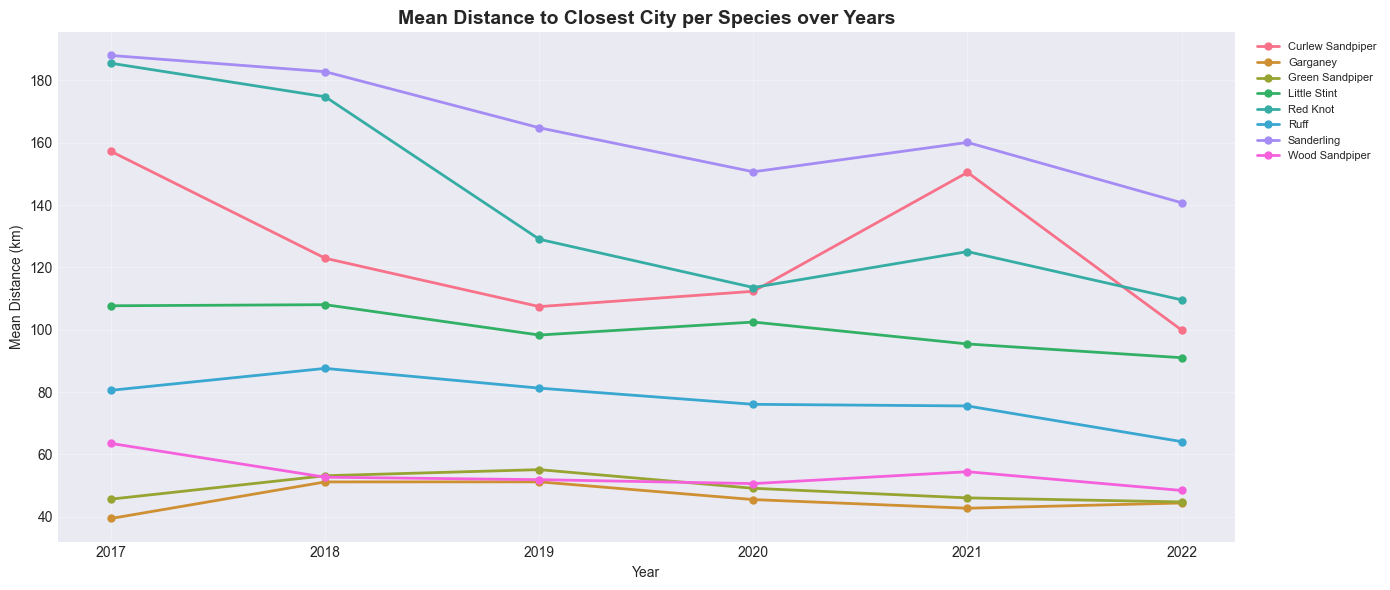

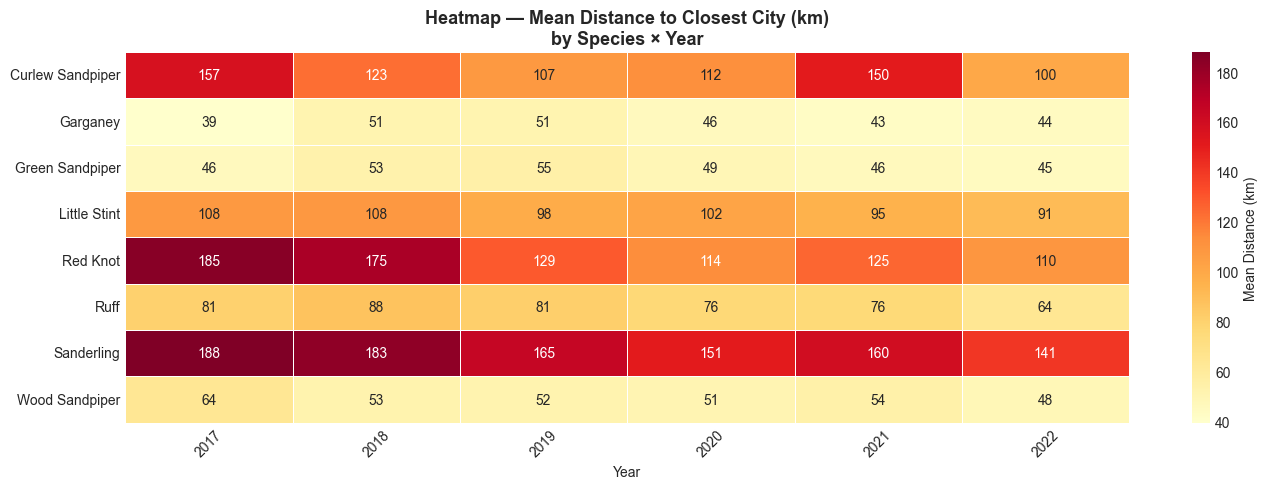

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Colour palette ──────────────────────────────────────────────────────────
species_list = dist_by_species_year['COMMON NAME'].unique()
palette = dict(zip(species_list, sns.color_palette("husl", len(species_list))))

# ============================================================
# PLOT 1 — Line plot: mean distance per species over years
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

for species, grp in dist_by_species_year.groupby('COMMON NAME'):
    ax.plot(grp['year'], grp['mean_distance_km'],
            marker='o', linewidth=2, markersize=5,
            label=species, color=palette[species])

ax.set_title('Mean Distance to Closest City per Species over Years', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Distance (km)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dist_species_year_lineplot.png', dpi=150)
plt.show()

# ============================================================
# PLOT 2 — Heatmap: pivot_mean (species × year)
# ============================================================
fig, ax = plt.subplots(figsize=(14, max(5, len(species_list) * 0.45)))

sns.heatmap(
    pivot_mean,
    ax=ax,
    cmap='YlOrRd',
    annot=True, fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Mean Distance (km)'}
)

ax.set_title('Heatmap — Mean Distance to Closest City (km)\nby Species × Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('dist_species_year_heatmap.png', dpi=150)
plt.show()


In [87]:
print(df_migratory['distance_km'].describe())
print(f"\nMedian:  {df_migratory['distance_km'].median():.2f} km")
print(f"Skewness: {df_migratory['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migratory['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migratory['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migratory['distance_km'] <= 100).mean()*100:.1f}%")

count    624063.000000
mean         81.639961
std         265.722092
min           0.060000
25%          20.720000
50%          35.650000
75%          58.940000
max        2460.870000
Name: distance_km, dtype: float64

Median:  35.65 km
Skewness: 6.74
% within 10km:  8.8%
% within 50km:  66.5%
% within 100km: 92.4%
